# Orchestrating Multi-Agent Sales Workflow with LLMs
This notebook demonstrates how to orchestrate multiple AI agents using the OpenAI Agents SDK and an Ollama model. Three specialized sales agents independently generate cold emails, a Sales Manager evaluates them, and the winning email is sent using an email tool.

In [1]:
from dotenv import load_dotenv
import requests
from openai import AsyncOpenAI
from agents import Agent, Runner, trace, function_tool, ModelSettings, set_tracing_disabled
from agents.models.openai_chatcompletions import OpenAIChatCompletionsModel
from openai.types.responses import ResponseTextDeltaEvent
from agents.extensions.visualization import draw_graph
from openai.types.responses import ResponseTextDeltaEvent
import os
import html
import asyncio
import smtplib
from email.message import EmailMessage
load_dotenv(override=True)
set_tracing_disabled(True)
MODEL_NAME = "llama3.2:latest"
ollama_client = AsyncOpenAI(
    base_url="http://localhost:11434/v1",
    api_key="ollama",  # Dummy value required by the client
)

ollama_model = OpenAIChatCompletionsModel(
    model=MODEL_NAME,
    openai_client=ollama_client,
)

## 1. Import Libraries and Configure the Environment
Import the required libraries, configure the local LLM, and load environment variables for SMTP email delivery.

In [2]:
EMAIL_ADDRESS = os.getenv("EMAIL_ADDRESS")
EMAIL_SMTP_SERVER = os.getenv("EMAIL_SMTP_SERVER")
EMAIL_APP_PASSWORD = os.getenv("EMAIL_APP_PASSWORD")

if EMAIL_ADDRESS:
    print("Email address is set")
else:
    print("Email address is not set")

if EMAIL_SMTP_SERVER:
    print("SMTP server is set")
else:
    print("SMTP server is not set")

if EMAIL_APP_PASSWORD:
    print("App password is set")
else:
    print("App password is not set")

USE_EMAIL = EMAIL_ADDRESS and EMAIL_SMTP_SERVER and EMAIL_APP_PASSWORD

if USE_EMAIL:
    print("Email is set up and we will try using it")
else:
    print("Email is not set up; we will send push notifications instead")

Email address is set
SMTP server is set
App password is set
Email is set up and we will try using it


## 2. Configure Email Credentials
Load the SMTP configuration from environment variables that will later be used by the email sending tool.

In [3]:
intro = """
You are a sales agent working for ComplAI, 
a company that provides a SaaS tool for ensuring SOC2 compliance and preparing for audits, powered by AI.
You write emails.
"""

instructions1 = intro + "Your email style is professional, serious, with gravitas and credibility."
instructions2 = intro + "Your email style is witty, engaging, and humorous."
instructions3 = intro + "Your email style is concise, to the point, in the style of a busy senior executive."

## 3. Define the Sales Agent Prompts
Create three different sales personas that generate diverse cold outreach emails.

In [4]:
sales_agent1 = Agent(name="Professional Sales Agent", instructions=instructions1, model=ollama_model)
sales_agent2 = Agent(name="Humorous Sales Agent", instructions=instructions2, model=ollama_model)
sales_agent3 = Agent(name="Executive Sales Agent", instructions=instructions3, model=ollama_model)

## 4. Create the Sales Agents
Instantiate three independent agents that each produce a unique sales email.

In [5]:
def send_email(subject, text_body, html_body):
    if not EMAIL_ADDRESS or not EMAIL_SMTP_SERVER or not EMAIL_APP_PASSWORD:
        raise ValueError("Email configuration is missing from .env")

    msg = EmailMessage()
    msg["From"] = EMAIL_ADDRESS
    msg["To"] = EMAIL_ADDRESS
    msg["Subject"] = subject
    msg.set_content(text_body)
    msg.add_alternative(html_body, subtype="html")

    try:
        with smtplib.SMTP(EMAIL_SMTP_SERVER, 587, timeout=30) as server:
            server.ehlo()
            server.starttls()
            server.ehlo()
            server.login(EMAIL_ADDRESS, EMAIL_APP_PASSWORD)
            server.send_message(msg)

        print("Email sent successfully")

    except Exception as error:
        print("Email sending failed:", repr(error))
        raise

## 5. Implement the Email Sending Function
Create a reusable function that sends plain-text and HTML emails via SMTP.

In [6]:


@function_tool
def send_email_tool(
    subject: str,
    text_body: str,
    html_body: str = "",
) -> str:
    """Send the selected sales email."""

    print("✅ TOOL EXECUTED")
    print("Subject:", subject)
    print("Text body:", text_body)
    print("HTML body:", repr(html_body))

    # Replace missing or malformed HTML with safe HTML generated
    # from the plain-text email.
    if not html_body or "<" not in html_body or ">" not in html_body:
        escaped_body = html.escape(text_body)
        html_body = (
            "<html><body>"
            f"<p>{escaped_body.replace(chr(10), '<br>')}</p>"
            "</body></html>"
        )

    send_email(subject, text_body, html_body)
    return "Email sent successfully"

## 6. Wrap the Email Function as a Tool
Expose the email sender as a tool that can be called programmatically.

In [7]:
description = "Use this tool to write a sales email. In the input, just instruct it to write a sales email."

tool1 = sales_agent1.as_tool(tool_name="sales_email_writer_1", tool_description=description)
tool1

FunctionTool(name='sales_email_writer_1', description='Use this tool to write a sales email. In the input, just instruct it to write a sales email.', params_json_schema={'properties': {'input': {'title': 'Input', 'type': 'string'}}, 'required': ['input'], 'title': 'sales_email_writer_1_args', 'type': 'object', 'additionalProperties': False}, on_invoke_tool=<function function_tool.<locals>._create_function_tool.<locals>._on_invoke_tool at 0x749177241580>, strict_json_schema=True, is_enabled=True, tool_input_guardrails=None, tool_output_guardrails=None)

## 7. Convert Agents into Tools
Wrap each sales agent as a reusable tool so they can be orchestrated within the workflow.

In [8]:
tool1 = sales_agent1.as_tool(tool_name="sales_email_writer_1", tool_description=description)
tool2 = sales_agent2.as_tool(tool_name="sales_email_writer_2", tool_description=description)
tool3 = sales_agent3.as_tool(tool_name="sales_email_writer_3", tool_description=description)

tools = [tool1, tool2, tool3, send_email_tool]

tools

[FunctionTool(name='sales_email_writer_1', description='Use this tool to write a sales email. In the input, just instruct it to write a sales email.', params_json_schema={'properties': {'input': {'title': 'Input', 'type': 'string'}}, 'required': ['input'], 'title': 'sales_email_writer_1_args', 'type': 'object', 'additionalProperties': False}, on_invoke_tool=<function function_tool.<locals>._create_function_tool.<locals>._on_invoke_tool at 0x7491772423e0>, strict_json_schema=True, is_enabled=True, tool_input_guardrails=None, tool_output_guardrails=None),
 FunctionTool(name='sales_email_writer_2', description='Use this tool to write a sales email. In the input, just instruct it to write a sales email.', params_json_schema={'properties': {'input': {'title': 'Input', 'type': 'string'}}, 'required': ['input'], 'title': 'sales_email_writer_2_args', 'type': 'object', 'additionalProperties': False}, on_invoke_tool=<function function_tool.<locals>._create_function_tool.<locals>._on_invoke_tool 

## 8. Define the Sales Manager
Create the Sales Manager agent responsible for reviewing the three drafts, selecting the strongest one, and preparing it for sending.

In [17]:
instructions = """
You are the Sales Manager at ComplAI.

Your job is to coordinate three sales-writing tools, compare their outputs,
select the strongest cold sales email, and send exactly one email.

You must use tools to complete the workflow.
Do not write or simulate tool calls as JSON in your response.
Do not generate the sales email yourself.
Do not stop after calling only one writer tool.
"""

task = """
Complete the workflow in this exact order:

1. Call sales_email_writer_1 exactly once with this instruction:
   "Write a cold sales email for ComplAI."

2. Call sales_email_writer_2 exactly once with this instruction:
   "Write a cold sales email for ComplAI."

3. Call sales_email_writer_3 exactly once with this instruction:
   "Write a cold sales email for ComplAI."

4. Wait until you have received all three complete drafts.

5. Compare the three drafts based on:
   - clarity,
   - professionalism,
   - relevance to SOC 2 compliance,
   - persuasiveness,
   - likelihood of receiving a reply.

6. Select exactly one winning draft.

7. Call send_email_tool exactly once using:
   - subject: a clear subject line for the selected email,
   - text_body: the complete selected email body,
   - html_body: an HTML version of the same email, or an empty string.

8. After send_email_tool succeeds, return only:
   Email sent successfully.

Important rules:
- Use every sales_email_writer tool exactly once.
- Do not send more than one email.
- Do not expose tool-call JSON as your final answer.
- Do not include analysis or explanations in the final answer.
"""

sales_manager = Agent(name="Sales Manager", instructions=instructions, tools=tools, model=ollama_model)

## 9. Visualize the Agent Graph
Display the orchestration graph showing the relationships between agents and tools.

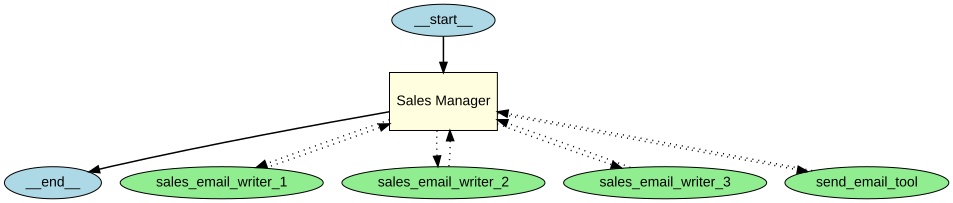

In [18]:
draw_graph(sales_manager)

## 10. Run the Orchestration Workflow
Execute the workflow, compare the generated drafts, choose the best email, and send it.

In [19]:
sales_manager = Agent(
    name="Sales Manager",
    instructions=instructions,
    tools=tools,
    model=ollama_model,
)

with trace("Sales manager"):
    result = await Runner.run(sales_manager, task)

print("\n===== FINAL OUTPUT =====")
print(result.final_output)


===== FINAL OUTPUT =====
{"name": "sales_email_writer_1", "parameters": {"error":"Invalid JSON input for tool sales_email_writer_1: 1 validation error for sales_email_writer_1_args\ninput\n  Write a cold sales email for ComplAI.\nInput should be a valid string [type=string_type, input_value=\"\u00beWrite a cold sales email for ComplAI.\u00b7\"\ ]"}}


## Summary
In this notebook you learned how to:
- Build multiple specialized agents.
- Orchestrate agent collaboration.
- Compare AI-generated outputs.
- Use an AI manager to select the best result.
- Integrate external tools (SMTP email) into an agent workflow.